In [ ]:
#rou net cfg file
#Upload OSM FILE

In [ ]:
!pip install sumolib traci


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 150.9/150.9 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.4/126.4 kB 5.5 MB/s eta 0:00:00


In [ ]:
!sudo add-apt-repository ppa:sumo/stable
!sudo apt-get update
!sudo apt-get install sumo sumo-tools sumo-doc
!sumo --version


Repository: 'deb https://ppa.launchpadcontent.net/sumo/stable/ubuntu/ jammy main'
Description:
SUMO is a highly portable, microscopic traffic simulation package designed to handle large road networks. SUMO is open source, licensed under the EPLv2.
More info: https://launchpad.net/~sumo/+archive/ubuntu/stable
Adding repository.
Press [ENTER] to continue or Ctrl-c to cancel.
Adding deb entry to /etc/apt/sources.list.d/sumo-ubuntu-stable-jammy.list
Adding disabled deb-src entry to /etc/apt/sources.list.d/sumo-ubuntu-stable-jammy.list
Adding key to /etc/apt/trusted.gpg.d/sumo-ubuntu-stable.gpg with fingerprint 7604B28616B7E70EC0E6D840C32412BB1ADB414B
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://ar

In [ ]:
#!which sumo
!sumo --version






Eclipse SUMO sumo Version 1.22.0
 Build features: Linux-6.8.0-51-generic x86_64 GNU 11.4.0 Release FMI Proj GUI Intl SWIG Eigen GDAL GL2PS
 Copyright (C) 2001-2025 German Aerospace Center (DLR) and others; https://sumo.dlr.de

Eclipse SUMO sumo Version 1.22.0 is part of SUMO.
This program and the accompanying materials
are made available under the terms of the Eclipse Public License v2.0
which accompanies this distribution, and is available at
http://www.eclipse.org/legal/epl-v20.html
This program may also be made available under the following Secondary
Licenses when the conditions for such availability set forth in the Eclipse
Public License 2.0 are satisfied: GNU General Public License, version 2
or later which is available at
https://www.gnu.org/licenses/old-licenses/gpl-2.0-standalone.html
SPDX-License-Identifier: EPL-2.0 OR GPL-2.0-or-later


In [ ]:
import os
os.environ["SUMO_HOME"] = "/usr/share/sumo"

!netconvert \
--osm-files /content/map.osm \
--output-file /content/freedom_park.net.xml \



Success.


In [ ]:
import os
os.environ["SUMO_HOME"] = "/usr/share/sumo/tools"

!python3 /usr/share/sumo/tools/randomTrips.py \
-n /content/freedom_park.net.xml \
-o /content/freedom_park.trips.xml \
-e 86400


In [ ]:
!duarouter -n freedom_park.net.xml -t freedom_park.trips.xml -o freedom_park.rou.xml --ignore-errors true


Streaming output truncated to the last 5000 lines.
Success.


In [ ]:
!echo '<?xml version="1.0" encoding="UTF-8"?>' > /content/freedom_park.sumocfg
!echo '<configuration>' >> /content/freedom_park.sumocfg
!echo '    <input>' >> /content/freedom_park.sumocfg
!echo '        <net-file value="freedom_park.net.xml"/>' >> /content/freedom_park.sumocfg
!echo '        <route-files value="freedom_park.rou.xml"/>' >> /content/freedom_park.sumocfg
!echo '    </input>' >> /content/freedom_park.sumocfg
!echo '    <time>' >> /content/freedom_park.sumocfg
!echo '        <begin value="0"/>' >> /content/freedom_park.sumocfg
!echo '        <end value="86400"/>' >> /content/freedom_park.sumocfg
!echo '    </time>' >> /content/freedom_park.sumocfg
!echo '</configuration>' >> /content/freedom_park.sumocfg


In [ ]:
import traci
import math
import csv
import time

# GUI mode toggle (set to "1" if you want to see visuals)
gui_mode = "0"  # change to "1" if running with SUMO-GUI

# SUMO binary (switch to "sumo-gui" if using GUI mode)
sumo_binary = "sumo-gui" if gui_mode == "1" else "sumo"

# Start SUMO with verbose logging
traci.start([sumo_binary, "-c", r"/content/freedom_park.sumocfg", "--start"])
time.sleep(2)  # Allow SUMO to initialize

#Tracking Locations (x, y, radius, name)
tracking_points = [
    (590.85, 1079.43, 50.0, "Junction 1"),
    (1566.25, 1260.03, 50.0, "Big Roundabout"),
    (1043.77, 1175.63, 50.0, "Junction 2"),
    (771.77, 1354.39, 50.0, "Junction 3"),
    (971.33, 1673.16, 50.0, "Junction 4"),
    (1245.12, 1491.37, 50.0, "Junction 5")
]

# Visual colors
circle_color = (0, 0, 255, 100)  # Blue
label_color = (255, 255, 255, 255)  # White

# Draw a detection circle at a point
def draw_detection_zone(point_id, position, radius, color):
    points = [
        (position[0] + radius * math.cos(angle), position[1] + radius * math.sin(angle))
        for angle in [i * (math.pi / 10) for i in range(21)]
    ]
    traci.polygon.add(f"detection_{point_id}", points, color, fill=True, layer=1)

# Label each point
def add_label(label_id, position, name, color):
    traci.poi.add(poiID=label_id, x=position[0], y=position[1], color=color)
    print(f"Added label: {name} at {position}")

# Show visuals only if in GUI mode
if gui_mode == "1":
    for i, (x, y, radius, name) in enumerate(tracking_points):
        draw_detection_zone(i, (x, y), radius, circle_color)
        add_label(f"label_{i}", (x, y), name, label_color)

def update_traffic_scale(time_step):
    hour = (time_step // 3600) % 24
    if hour <= 0:
        scale = 0.317
    elif hour <= 1:
        scale = 0.250
    elif hour <= 2:
        scale = 0.226
    elif hour <= 3:
        scale = 0.200
    elif hour <= 4:
        scale = 0.208
    elif hour <= 5:
        scale = 0.243
    elif hour <= 6:
        scale = 0.293
    elif hour <= 7:
        scale = 0.665
    elif hour <= 8:
        scale = 0.805
    elif hour <= 9:
        scale = 0.876
    elif hour <= 10:
        scale = 0.900
    elif hour <= 11:
        scale = 0.861
    elif hour <= 12:
        scale = 0.873
    elif hour <= 13:
        scale = 0.849
    elif hour <= 14:
        scale = 0.856
    elif hour <= 15:
        scale = 0.837
    elif hour <= 16:
        scale = 0.817
    elif hour <= 17:
        scale = 0.844
    elif hour <= 18:
        scale = 0.797
    elif hour <= 19:
        scale = 0.262
    elif hour <= 20:
        scale = 0.270
    elif hour <= 21:
        scale = 0.257
    elif hour <= 22:
        scale = 0.253
    elif hour <= 23:
        scale = 0.246
    else:
        scale = 0.317  # fallback

    traci.simulation.setScale(scale)

with open("junction_data.csv", "w", newline="") as csvfile:
    fieldnames = ["Time"] + [name for _, _, _, name in tracking_points]
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()

    # Simulation loop
    simulation_time = 86400  # full 24 hours
    for step in range(simulation_time):
        traci.simulationStep()

        #Print progress every 60 steps
        if step % 60 == 0:
            hour = (step // 3600) % 24
            print(f"Sim Time: {step}s | Hour: {hour}")

        # Update traffic scale
        update_traffic_scale(traci.simulation.getTime())

        # Detect vehicles near each tracking point
        vehicle_counts = {"Time": step}
        for x, y, radius, name in tracking_points:
            count = 0
            for vehicle in traci.vehicle.getIDList():
                vx, vy = traci.vehicle.getPosition(vehicle)
                if math.hypot(vx - x, vy - y) <= radius:
                    count += 1
            vehicle_counts[name] = count

        writer.writerow(vehicle_counts)

traci.close()
print("Simulation completed and data saved.")


 Retrying in 1 seconds
Sim Time: 0s | Hour: 0
Sim Time: 60s | Hour: 0
Sim Time: 120s | Hour: 0
Sim Time: 180s | Hour: 0
Sim Time: 240s | Hour: 0
Sim Time: 300s | Hour: 0
Sim Time: 360s | Hour: 0
Sim Time: 420s | Hour: 0
Sim Time: 480s | Hour: 0
Sim Time: 540s | Hour: 0
Sim Time: 600s | Hour: 0
Sim Time: 660s | Hour: 0
Sim Time: 720s | Hour: 0
Sim Time: 780s | Hour: 0
Sim Time: 840s | Hour: 0
Sim Time: 900s | Hour: 0
Sim Time: 960s | Hour: 0
Sim Time: 1020s | Hour: 0
Sim Time: 1080s | Hour: 0
Sim Time: 1140s | Hour: 0
Sim Time: 1200s | Hour: 0
Sim Time: 1260s | Hour: 0
Sim Time: 1320s | Hour: 0
Sim Time: 1380s | Hour: 0
Sim Time: 1440s | Hour: 0
Sim Time: 1500s | Hour: 0
Sim Time: 1560s | Hour: 0
Sim Time: 1620s | Hour: 0
Sim Time: 1680s | Hour: 0
Sim Time: 1740s | Hour: 0
Sim Time: 1800s | Hour: 0
Sim Time: 1860s | Hour: 0
Sim Time: 1920s | Hour: 0
Sim Time: 1980s | Hour: 0
Sim Time: 2040s | Hour: 0
Sim Time: 2100s | Hour: 0
Sim Time: 2160s | Hour: 0
Sim Time: 2220s | Hour: 0
Sim Time:

In [ ]:
traci.close()

In [ ]:
from google.colab import files
files.download('/content/junction_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
file = "/content/junction_data.csv"
data = pd.read_csv(file)

# Drop the 'Time' column
data

,Time,Junction 1,Big Roundabout,Junction 2,Junction 3,Junction 4,Junction 5
0,0,0,0,0,0,0,1
1,1,0,0,0,0,0,1
2,2,0,0,0,0,0,1
3,3,0,0,0,0,0,1
4,4,0,1,0,0,0,1
...,...,...,...,...,...,...,...
86395,86395,0,0,1,1,0,0
86396,86396,0,0,1,1,0,0
86397,86397,0,0,1,1,0,0
86398,86398,0,0,1,1,0,0


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
file = "/content/merged_right_lane_counts.csv"
data = pd.read_csv(file)

# Drop the 'Time' column
data

,Time,file_1,file_2,file_3,file_4,file_5,Unnamed: 6,Unnamed: 7,Unnamed: 8
0,00:00:00,2,3,1,1,1,NaN,NaN,NaN
1,00:01:00,5,2,4,6,0,NaN,NaN,NaN
2,00:02:00,0,1,1,6,3,NaN,NaN,NaN
3,00:03:00,3,2,3,3,0,NaN,NaN,NaN
4,00:04:00,1,0,3,2,2,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
1448,23:55:00,1,2,1,0,3,NaN,NaN,NaN
1449,23:56:00,0,6,9,1,0,NaN,NaN,NaN
1450,23:57:00,5,3,0,1,4,NaN,NaN,NaN
1451,23:58:00,0,3,3,1,3,NaN,NaN,NaN


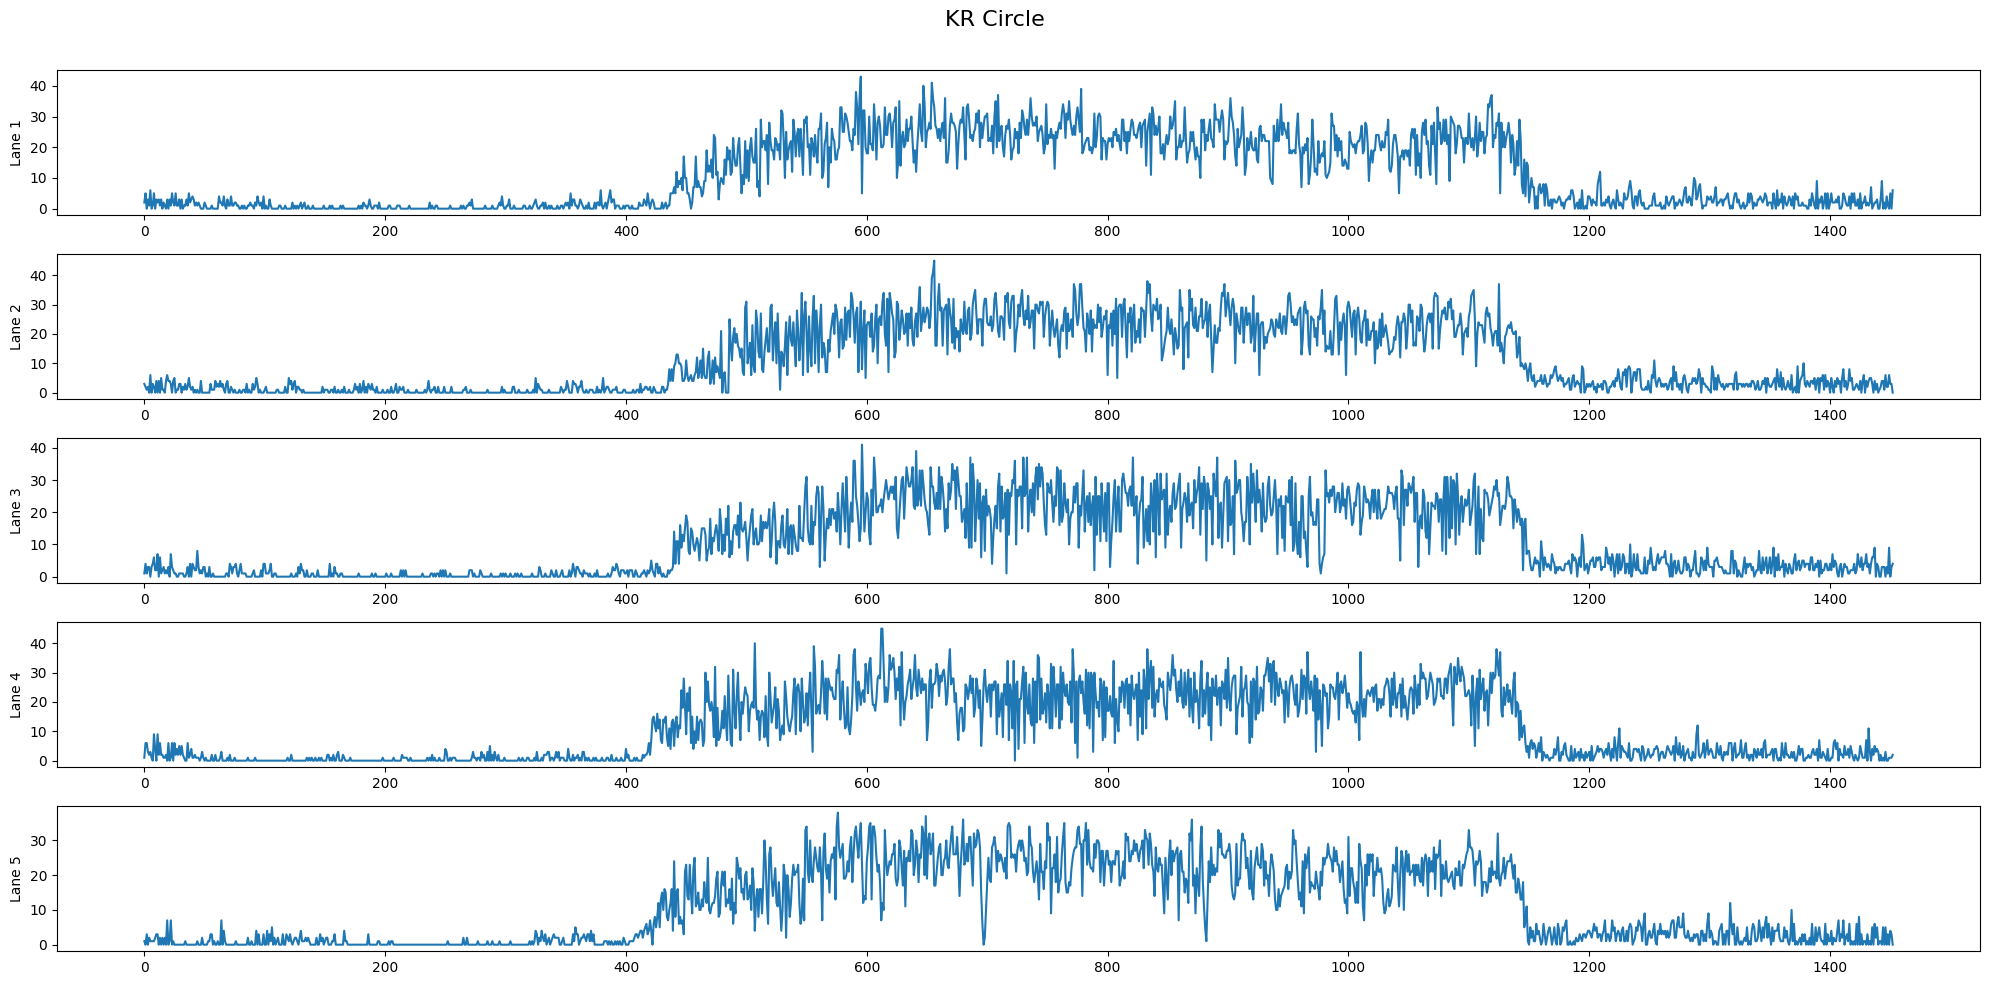

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

og_file = r"/content/merged_right_lane_counts.csv"
og_data = pd.read_csv(og_file)

# Extract each of the 5 columns (assuming columns 1-5 are numeric data)
og1 = og_data.iloc[:, 1]
og2 = og_data.iloc[:, 2]
og3 = og_data.iloc[:, 3]
og4 = og_data.iloc[:, 4]
og5 = og_data.iloc[:, 5]

# Create 5 vertically stacked subplots
fig, axs = plt.subplots(5, 1, figsize=(20, 10))
fig.suptitle("KR Circle", fontsize=16)

# Plot each series on its subplot
axs[0].plot(og1)
axs[1].plot(og2)
axs[2].plot(og3)
axs[3].plot(og4)
axs[4].plot(og5)

# Optional: label y-axes or add subplot titles
for i, ax in enumerate(axs):
    ax.set_ylabel(f"Lane {i+1}")

plt.tight_layout(rect=[0, 0, 1, 0.97])  # adjust for suptitle
plt.show()


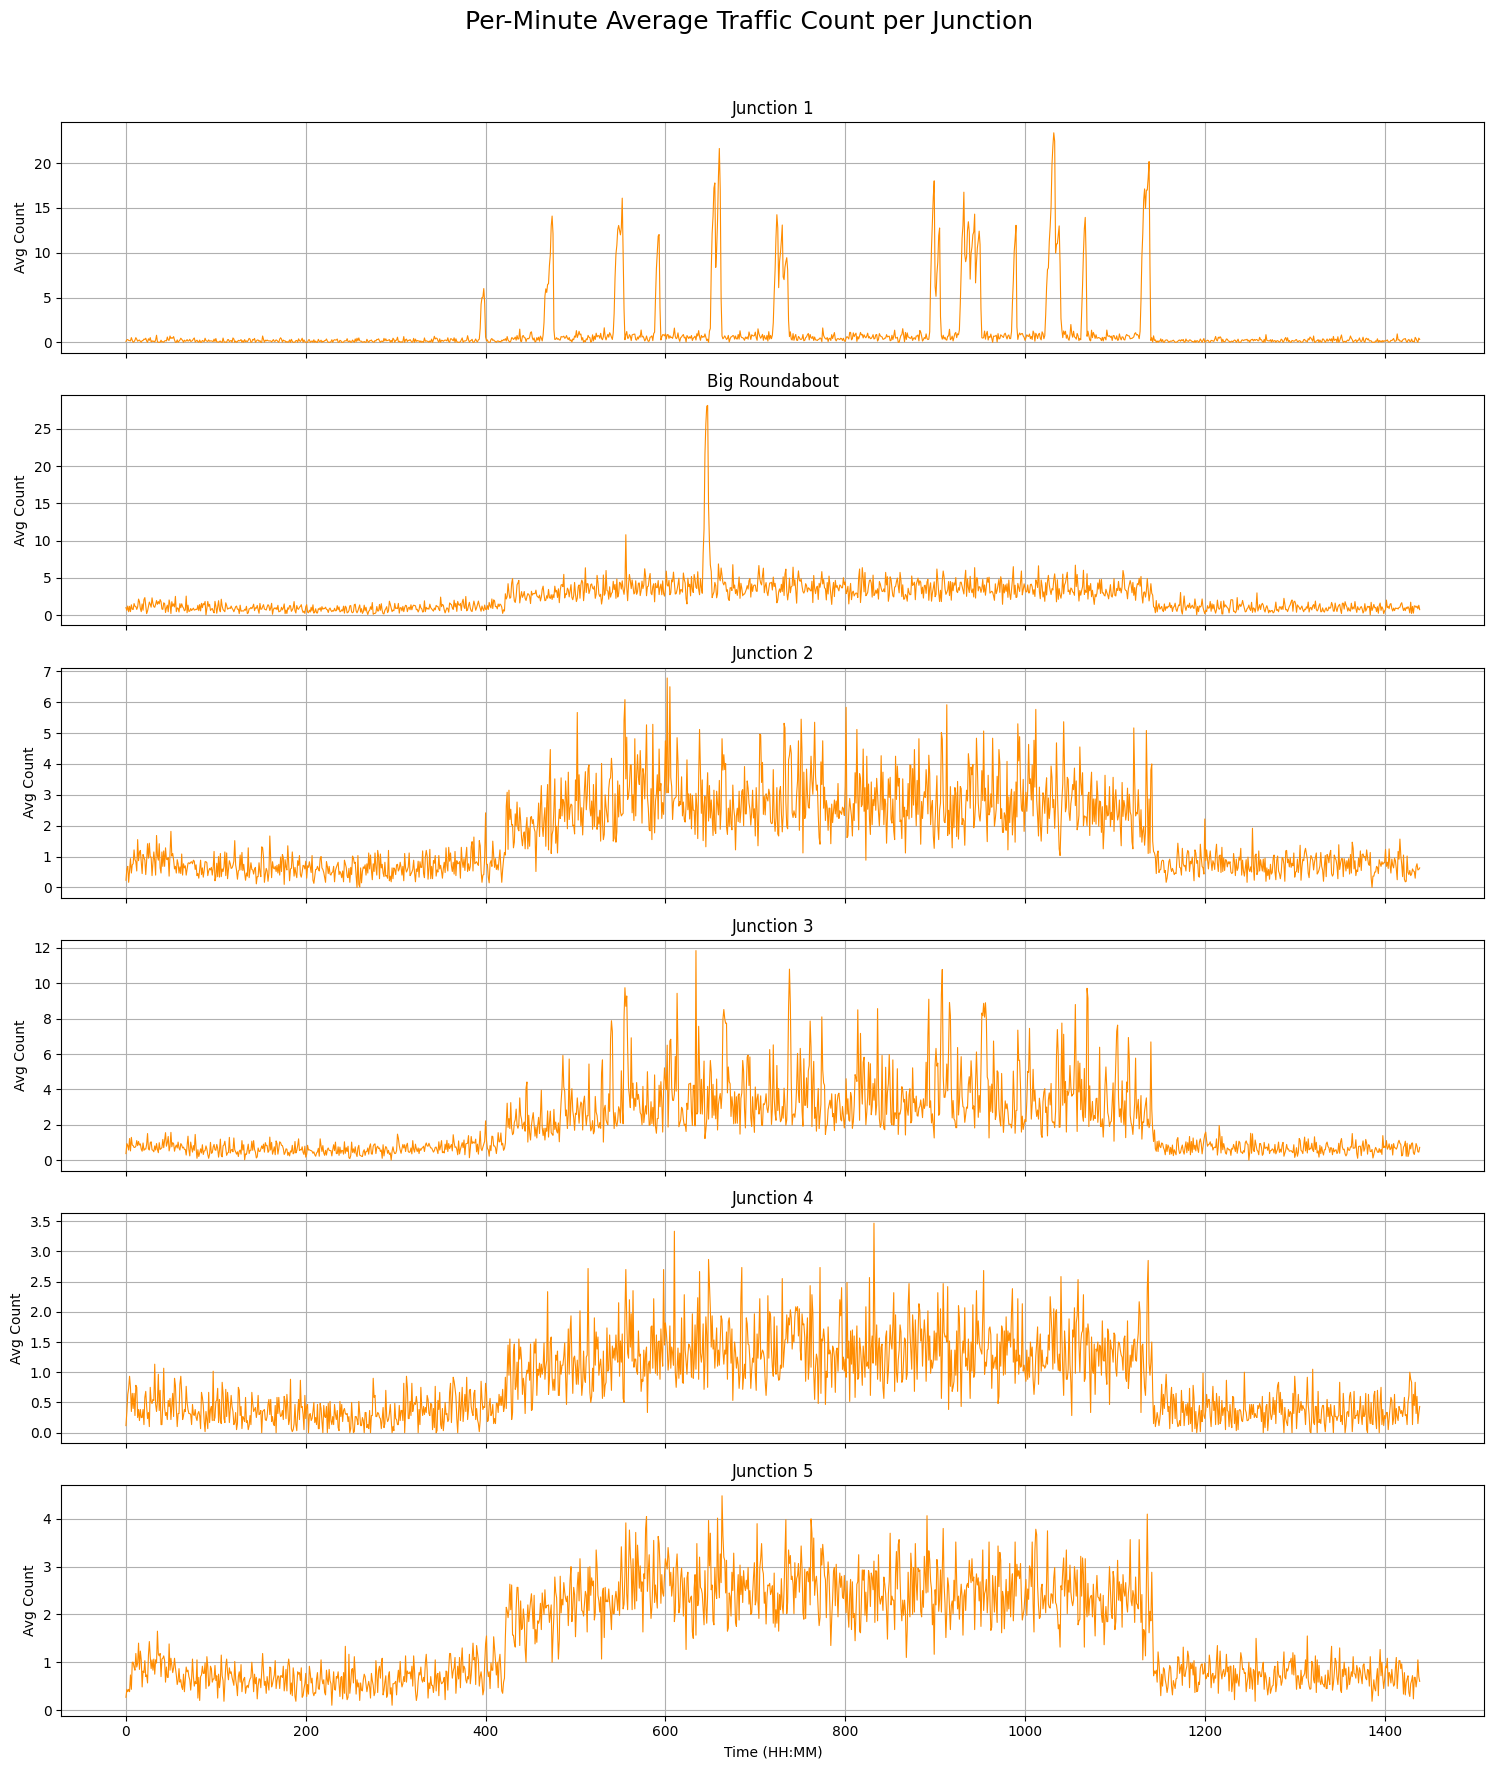

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
file = "/content/junction_data.csv"
data = pd.read_csv(file)

# Drop the 'Time' column
junction_data = data.drop(columns=['Time'])

# Resample per minute: group every 60 rows and take the mean
samples_per_minute = 60
minute_data = junction_data.groupby(junction_data.index // samples_per_minute).mean()

# Create subplots (one for each junction column)
num_junctions = minute_data.shape[1]
fig, axs = plt.subplots(num_junctions, 1, figsize=(15, 3 * num_junctions), sharex=True)

# Plot each junction’s per-minute averaged data
for i, col in enumerate(minute_data.columns):
    axs[i].plot(minute_data.index, minute_data[col], color='darkorange', linewidth=0.8)
    axs[i].set_title(col)
    axs[i].set_ylabel("Avg Count")
    axs[i].grid(True)

# Label the x-axis only for the last subplot
axs[-1].set_xlabel("Time (HH:MM)")

# Improve layout and spacing
fig.suptitle("Per-Minute Average Traffic Count per Junction", fontsize=18)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


In [ ]:
!pip install fastdtw

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean, cityblock
from scipy.stats import pearsonr, spearmanr
from fastdtw import fastdtw

# Function to compute all distance and similarity metrics
def compare_time_series(junction_data, merged_data):
    results = {}

    for junction_col in junction_data.columns:  # Loop over each junction's data
        file_comparison = []

        for i in range(1, 6):  # Loop over file_1 to file_5 in merged_data
            file_col = f"file_{i}"

            # Extract values from both time series
            junction_values = junction_data[junction_col].values
            file_values = merged_data[file_col].values

            # Calculate metrics for each file
            comparison_metrics = {
                "File": file_col,
                "Cosine Similarity": cosine_similarity([junction_values], [file_values])[0][0],
                "Manhattan Distance": cityblock(junction_values, file_values),
                "Euclidean Distance": euclidean(junction_values, file_values),
                "Pearson Correlation": pearsonr(junction_values, file_values)[0],
                "Spearman Correlation": spearmanr(junction_values, file_values)[0],
                "RMSE": np.sqrt(np.mean((junction_values - file_values) ** 2)),
                "MAE": np.mean(np.abs(junction_values - file_values)),
                "DTW Distance": fastdtw(junction_values, file_values)[0]
            }
            file_comparison.append(comparison_metrics)

        # Store the results for the current junction column
        results[junction_col] = pd.DataFrame(file_comparison)

    return results

# Example usage of the function
junction_data = pd.read_csv("/content/junction_data.csv")
merged_data = pd.read_csv("/content/merged_right_lane_counts.csv")

# Convert the 'Time' column to datetime in both datasets
junction_data['Time'] = pd.to_datetime(junction_data['Time'], unit='s')
merged_data['Time'] = pd.to_datetime(merged_data['Time'], format='%H:%M:%S')

# Resample the junction data by minute and aggregate (sum or any other relevant function)
junction_data_minute = junction_data.resample('min', on='Time').sum()
merged_data.set_index('Time', inplace=True)

# Calculate similarity scores for each junction and file pair
similarities = compare_time_series(junction_data_minute, merged_data)

# Print the results
for junction, df in similarities.items():
    print(f"Junction: {junction}")
    print(df.to_string(index=False))
    print()  # Blank line for separation


Junction: Junction 1
  File  Cosine Similarity  Manhattan Distance  Euclidean Distance  Pearson Correlation  Spearman Correlation       RMSE       MAE  DTW Distance
file_1           0.458605              103169         7886.352959             0.293789              0.604788 207.823648 71.645139       98652.0
file_2           0.457261              103021         7885.971025             0.291398              0.607714 207.813583 71.542361       98211.0
file_3           0.452234              103372         7898.063560             0.284078              0.609037 208.132250 71.786111       98968.0
file_4           0.447102              103079         7890.908883             0.276727              0.615787 207.943707 71.582639       98714.0
file_5           0.444219              103280         7898.497832             0.270901              0.598722 208.143694 71.722222       98685.0

Junction: Big Roundabout
  File  Cosine Similarity  Manhattan Distance  Euclidean Distance  Pearson Correlation  S

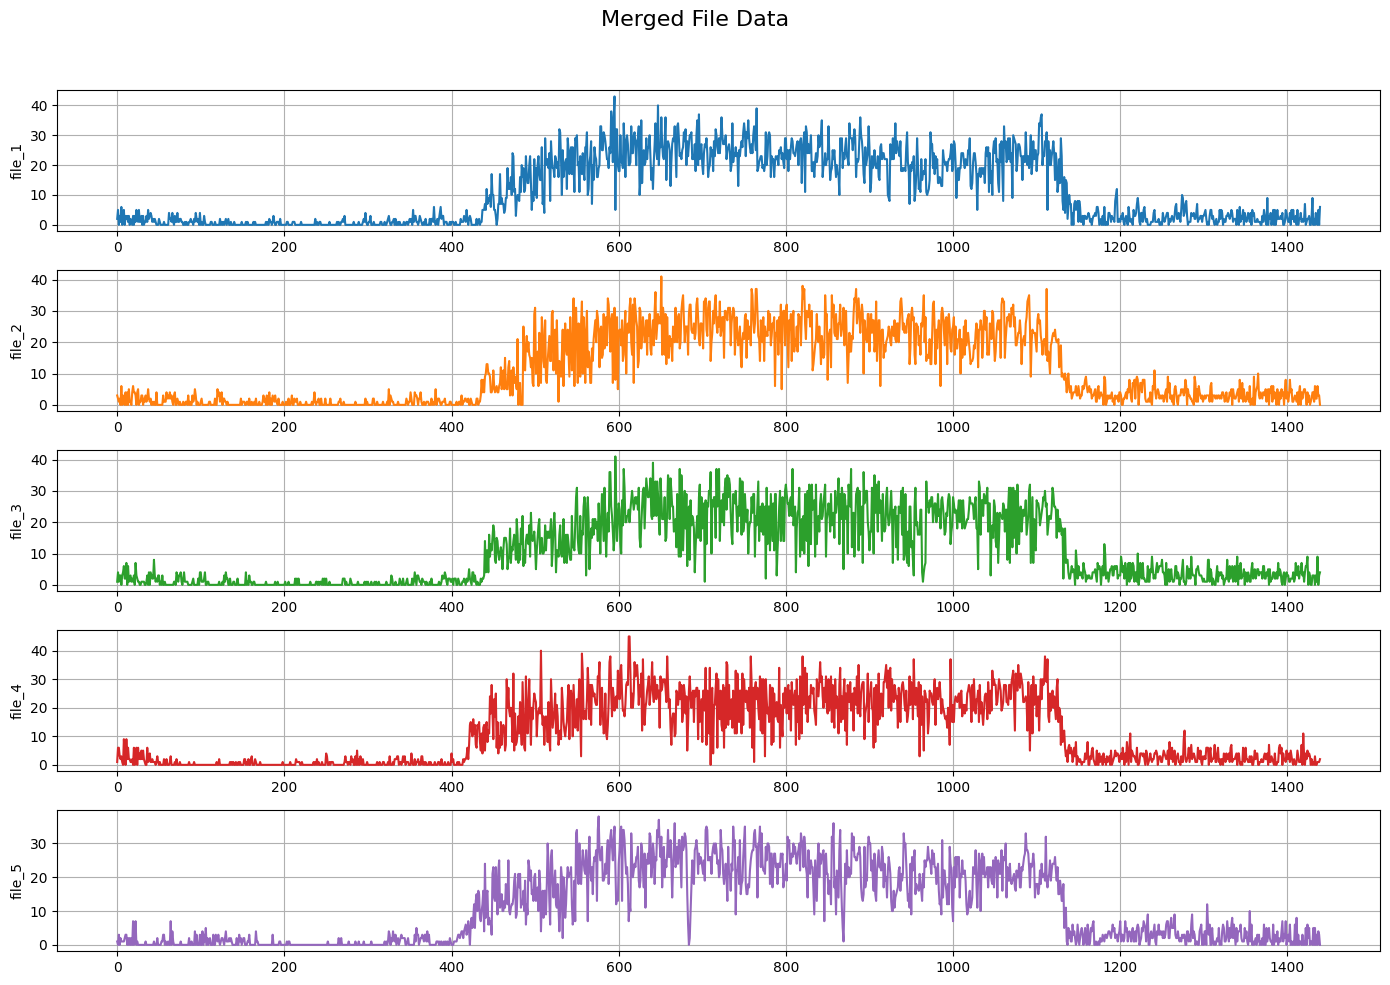

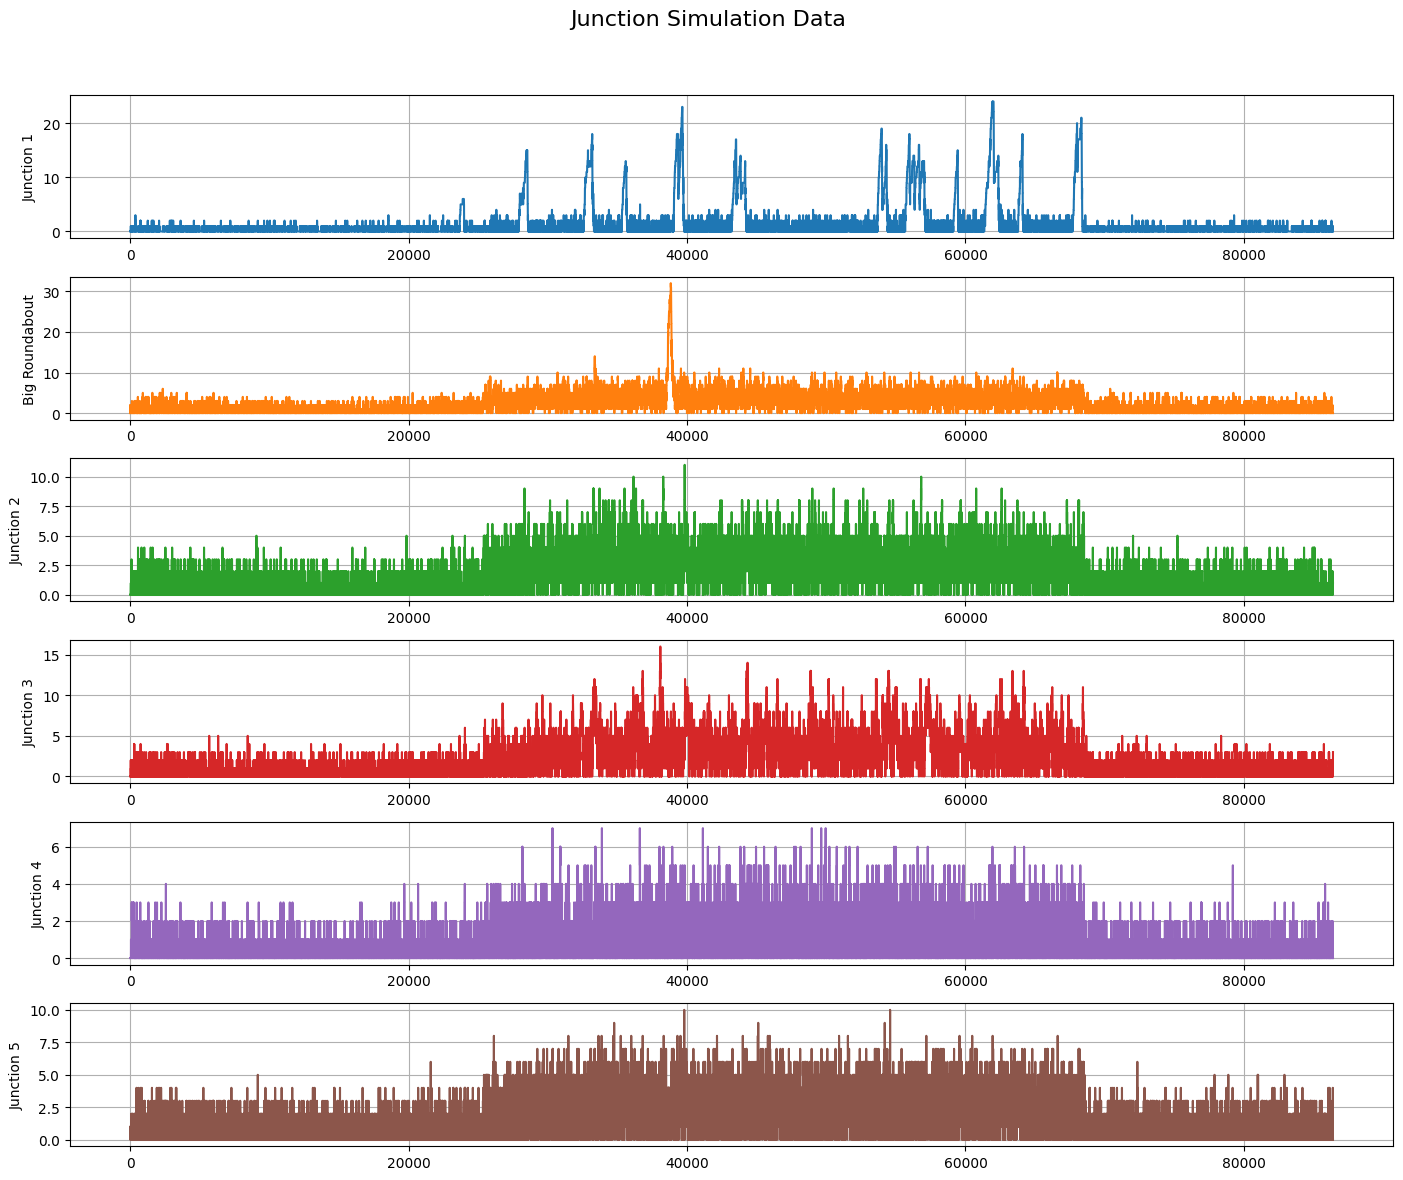

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the data
merged_data = pd.read_csv("/content/merged_right_lane_counts.csv")
junction_data = pd.read_csv("/content/junction_data.csv")

# ------- Merged Data Plot (5 files) --------
merged_cols = [col for col in merged_data.columns if col.startswith("file_")]

fig1, axs1 = plt.subplots(len(merged_cols), 1, figsize=(14, 10))
fig1.suptitle("Merged File Data", fontsize=16)

for i, col in enumerate(merged_cols):
    axs1[i].plot(merged_data[col], color=f"C{i}")
    axs1[i].set_ylabel(col)
    axs1[i].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# ------- Junction Data Plot (6 junctions) --------
junction_cols = [col for col in junction_data.columns if col != "Time"]

fig2, axs2 = plt.subplots(len(junction_cols), 1, figsize=(14, 12))
fig2.suptitle("Junction Simulation Data", fontsize=16)

for i, col in enumerate(junction_cols):
    axs2[i].plot(junction_data[col], color=f"C{i}")
    axs2[i].set_ylabel(col)
    axs2[i].grid(True)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()


<ipython-input-91-4bc53d0c71b9>:55: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i][j].legend()


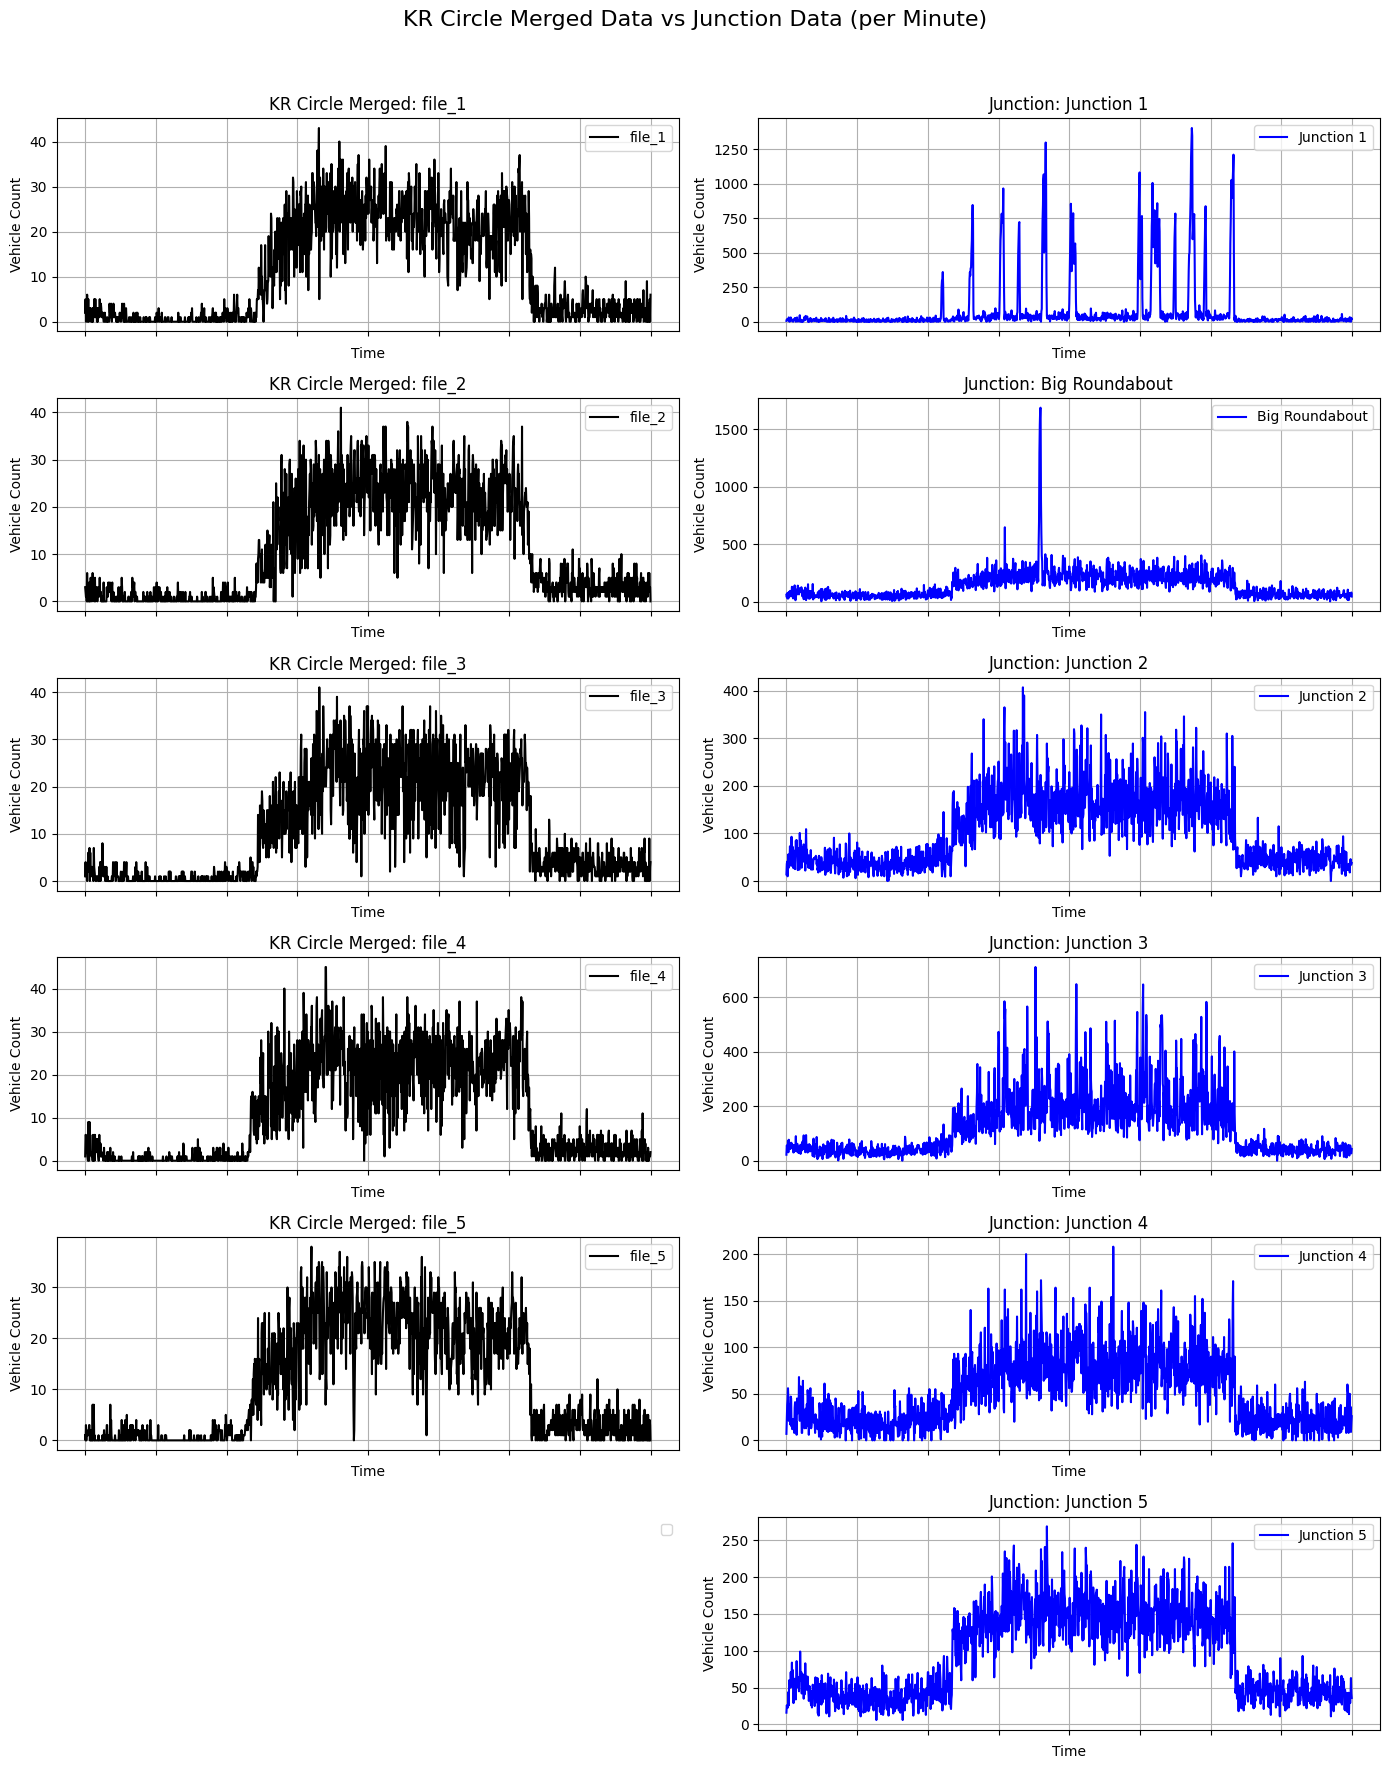

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# === Read merged (real) data ===
merged_data = pd.read_csv("/content/merged_right_lane_counts.csv")
merged_data = merged_data.dropna(axis=1, how='all')  # drop empty columns

if 'Unnamed: 8' in merged_data.columns:
    merged_data = merged_data.drop(columns=['Unnamed: 8'])

merged_data['Time'] = pd.to_datetime(merged_data['Time'], format='%H:%M:%S', errors='coerce')
merged_data = merged_data.dropna(subset=['Time'])
merged_data.set_index('Time', inplace=True)

# === Read junction (simulated) data ===
junction_data = pd.read_csv("/content/junction_data.csv")
junction_data['Time'] = pd.to_datetime(junction_data['Time'], unit='s')

# Resample junction data per minute
junction_minute = junction_data.resample('min', on='Time').sum().reset_index()
junction_minute.set_index('Time', inplace=True)

# === Plotting ===
merged_cols = [col for col in merged_data.columns if 'file_' in col]
junction_cols = [col for col in junction_minute.columns if col != 'Time']

# Determine the number of rows needed for plots
num_rows = max(len(merged_cols), len(junction_cols))

fig, axes = plt.subplots(num_rows, 2, figsize=(14, num_rows * 3))
fig.suptitle("KR Circle Merged Data vs Junction Data (per Minute)", fontsize=16)

# Ensure axes is always 2D
if num_rows == 1:
    axes = [axes]

for i in range(num_rows):
    # Plot merged data (left)
    if i < len(merged_cols):
        axes[i][0].plot(merged_data[merged_cols[i]], label=merged_cols[i], color="black")
        axes[i][0].set_title(f"KR Circle Merged: {merged_cols[i]}")
    else:
        axes[i][0].axis('off')

    # Plot junction data (right)
    if i < len(junction_cols):
        axes[i][1].plot(junction_minute[junction_cols[i]], label=junction_cols[i], color="blue")
        axes[i][1].set_title(f"Junction: {junction_cols[i]}")
    else:
        axes[i][1].axis('off')

    for j in range(2):
        axes[i][j].set_xlabel("Time")
        axes[i][j].set_ylabel("Vehicle Count")
        axes[i][j].legend()
        axes[i][j].grid(True)
        axes[i][j].set_xticklabels([])  # ← Remove x-axis tick labels

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()


<ipython-input-111-5a871d908971>:59: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i][j].legend()


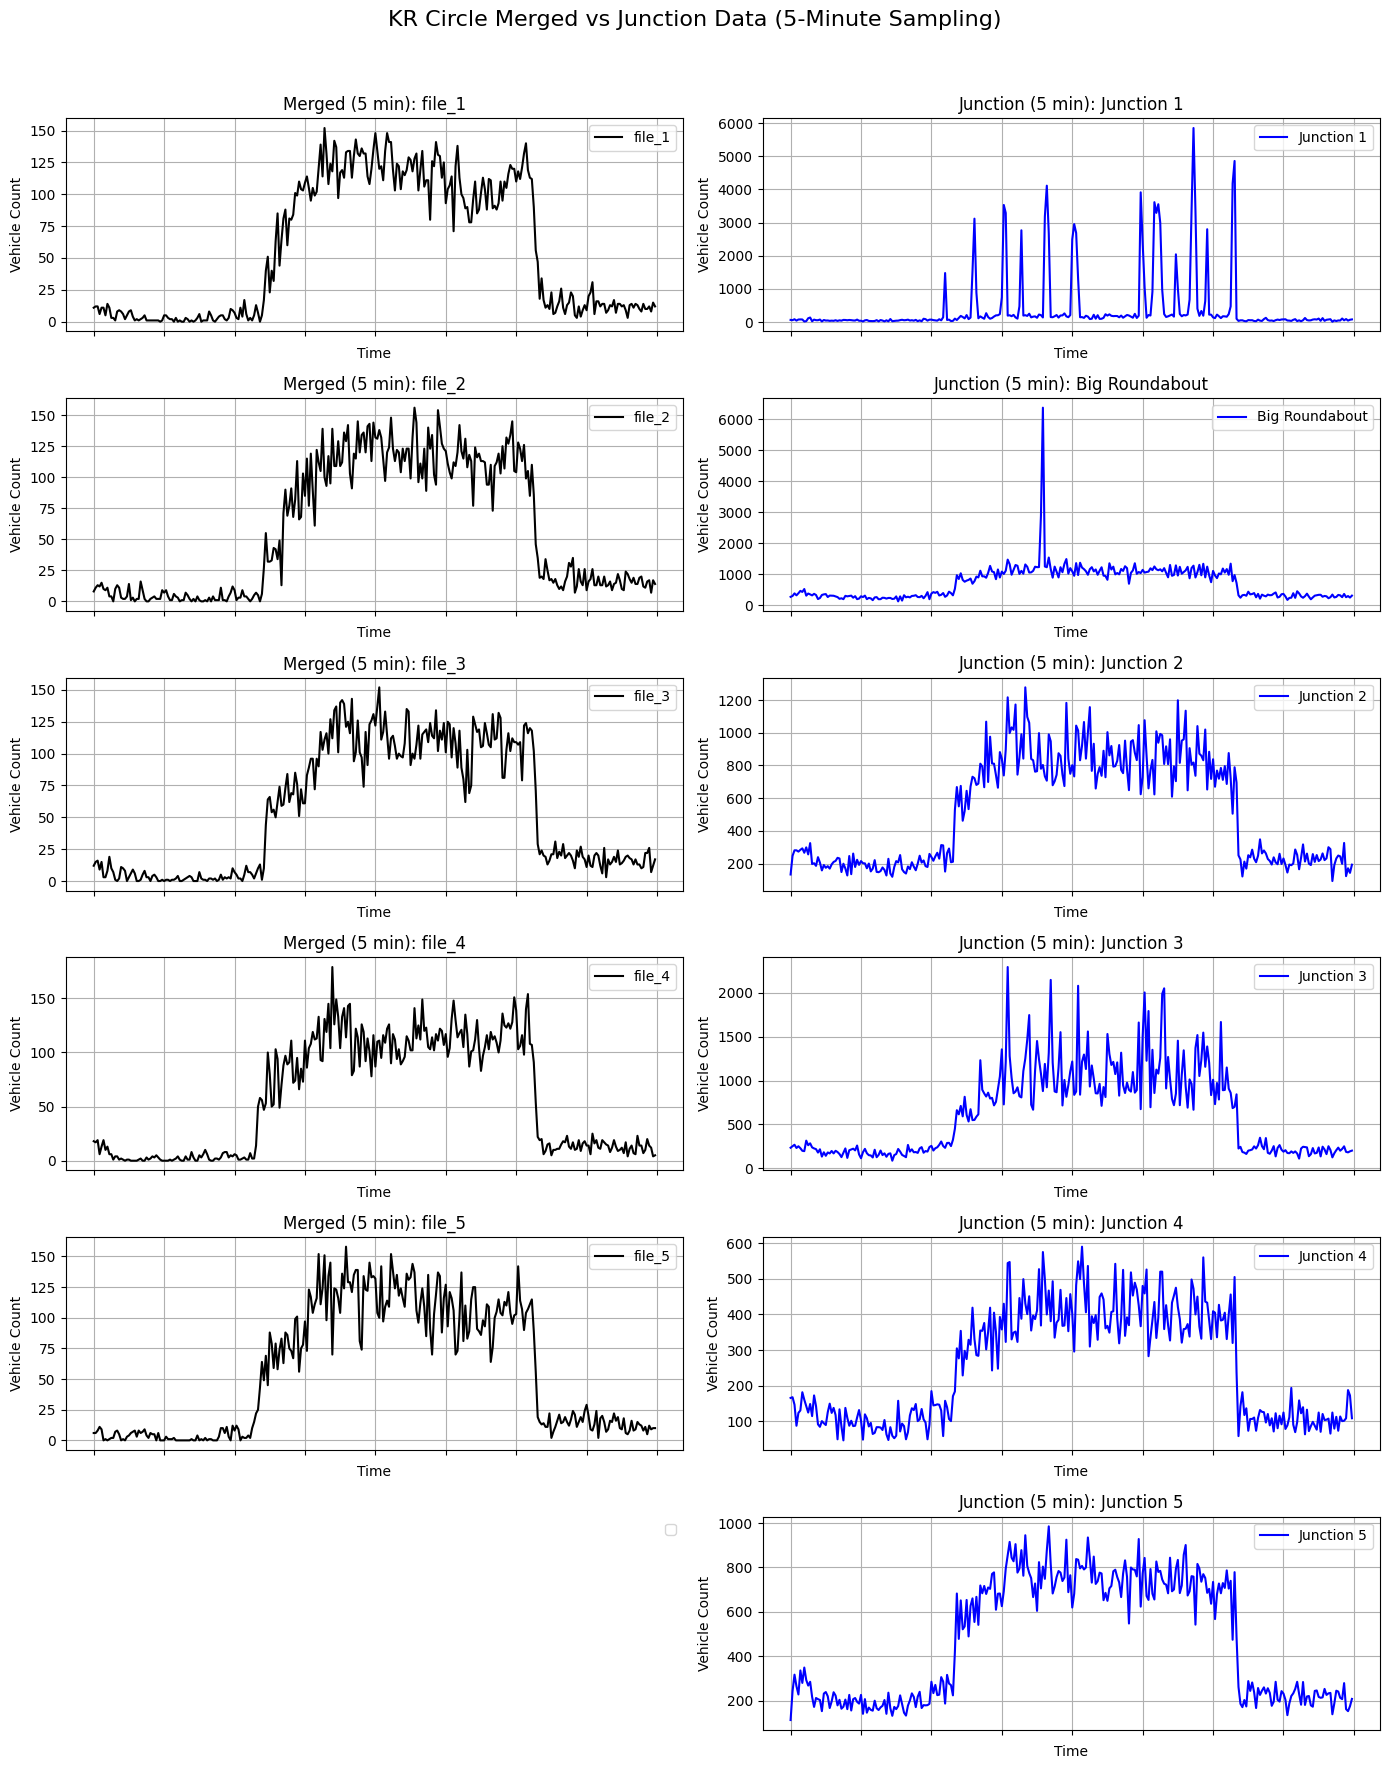

Junction: Junction 1
  File  Cosine Similarity  Manhattan Distance  Euclidean Distance  Pearson Correlation  Spearman Correlation       RMSE        MAE  DTW Distance
file_1           0.501492              100331        16412.601165             0.332443              0.732386 967.121798 348.371528       96669.0
file_2           0.500119              100117        16413.756943             0.329627              0.748801 967.189903 347.628472       95675.0
file_3           0.509199              100670        16430.978425             0.343525              0.750469 968.204689 349.548611       96951.0
file_4           0.496067               99929        16421.307835             0.322863              0.761964 967.634844 346.975694       95508.0
file_5           0.486149              100476        16441.182926             0.307204              0.734548 968.805995 348.875000       96308.0

Junction: Big Roundabout
  File  Cosine Similarity  Manhattan Distance  Euclidean Distance  Pearson Correlat

In [111]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean, cityblock
from scipy.stats import pearsonr, spearmanr
from fastdtw import fastdtw

# === Load merged data (real) ===
merged_data = pd.read_csv("/content/merged_right_lane_counts.csv")
merged_data = merged_data.dropna(axis=1, how='all')

if 'Unnamed: 8' in merged_data.columns:
    merged_data = merged_data.drop(columns=['Unnamed: 8'])

merged_data['Time'] = pd.to_datetime(merged_data['Time'], format='%H:%M:%S', errors='coerce')
merged_data = merged_data.dropna(subset=['Time'])
merged_data.set_index('Time', inplace=True)

# Resample to 5-minute intervals
merged_5min = merged_data.resample('5min').sum()

# === Load junction data (simulated) ===
junction_data = pd.read_csv("/content/junction_data.csv")
junction_data['Time'] = pd.to_datetime(junction_data['Time'], unit='s')

# Resample to 5-minute intervals
junction_5min = junction_data.resample('5min', on='Time').sum()

# === Plotting side by side ===
merged_cols = [col for col in merged_5min.columns if 'file_' in col]
junction_cols = [col for col in junction_5min.columns if col != 'Time']

num_rows = max(len(merged_cols), len(junction_cols))
fig, axes = plt.subplots(num_rows, 2, figsize=(14, num_rows * 3))
fig.suptitle("KR Circle Merged vs Junction Data (5-Minute Sampling)", fontsize=16)

if num_rows == 1:
    axes = [axes]

for i in range(num_rows):
    # Plot merged data
    if i < len(merged_cols):
        axes[i][0].plot(merged_5min[merged_cols[i]], label=merged_cols[i], color="black")
        axes[i][0].set_title(f"Merged (5 min): {merged_cols[i]}")
    else:
        axes[i][0].axis('off')

    # Plot junction data
    if i < len(junction_cols):
        axes[i][1].plot(junction_5min[junction_cols[i]], label=junction_cols[i], color="blue")
        axes[i][1].set_title(f"Junction (5 min): {junction_cols[i]}")
    else:
        axes[i][1].axis('off')

    for j in range(2):
        axes[i][j].set_xlabel("Time")
        axes[i][j].set_ylabel("Vehicle Count")
        axes[i][j].legend()
        axes[i][j].grid(True)
        axes[i][j].set_xticklabels([])

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# === Similarity Comparison ===

def compare_time_series(junction_data, merged_data):
    results = {}

    for junction_col in junction_data.columns:
        file_comparison = []

        for i in range(1, 6):
            file_col = f"file_{i}"
            if file_col not in merged_data.columns:
                continue

            # Drop NaNs and compare by sequence, not timestamp
            junction_series = junction_data[junction_col].dropna().values
            merged_series = merged_data[file_col].dropna().values

            min_len = min(len(junction_series), len(merged_series))
            if min_len == 0:
                continue

            junction_values = junction_series[:min_len]
            file_values = merged_series[:min_len]

            comparison_metrics = {
                "File": file_col,
                "Cosine Similarity": cosine_similarity([junction_values], [file_values])[0][0],
                "Manhattan Distance": cityblock(junction_values, file_values),
                "Euclidean Distance": euclidean(junction_values, file_values),
                "Pearson Correlation": pearsonr(junction_values, file_values)[0],
                "Spearman Correlation": spearmanr(junction_values, file_values)[0],
                "RMSE": np.sqrt(np.mean((junction_values - file_values) ** 2)),
                "MAE": np.mean(np.abs(junction_values - file_values)),
                "DTW Distance": fastdtw(junction_values, file_values)[0]
            }

            file_comparison.append(comparison_metrics)

        results[junction_col] = pd.DataFrame(file_comparison)

    return results

# Run similarity comparison
similarities = compare_time_series(junction_5min, merged_5min)

# Print results
for junction, df in similarities.items():
    print(f"Junction: {junction}")
    print(df.to_string(index=False))
    print()


<ipython-input-127-f5340d901c71>:101: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[i][j].legend()


Combined table image saved at /content/all_similarity_tables.png
Plot saved as 'merged_vs_junction_plots.png'


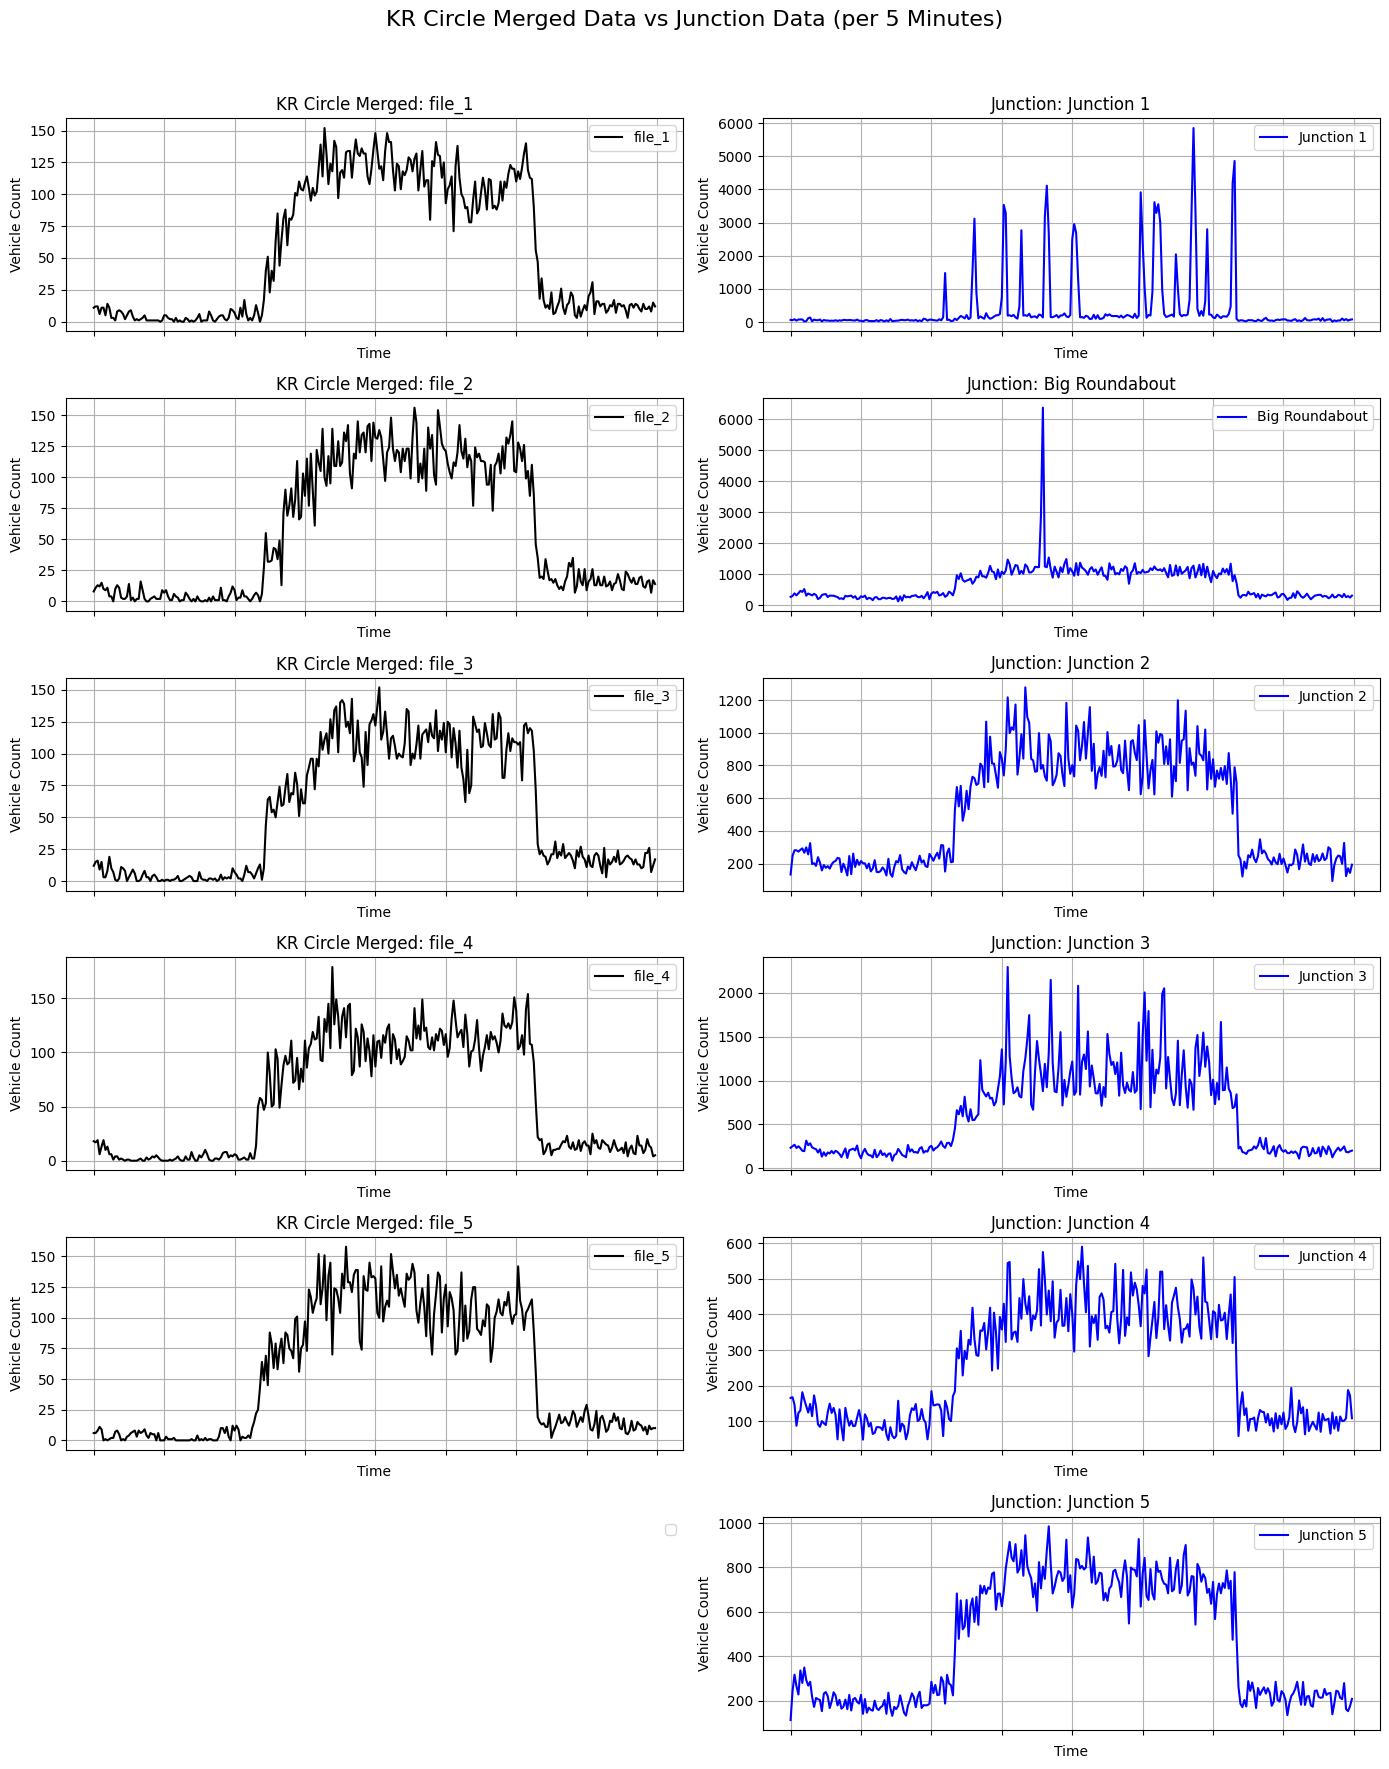

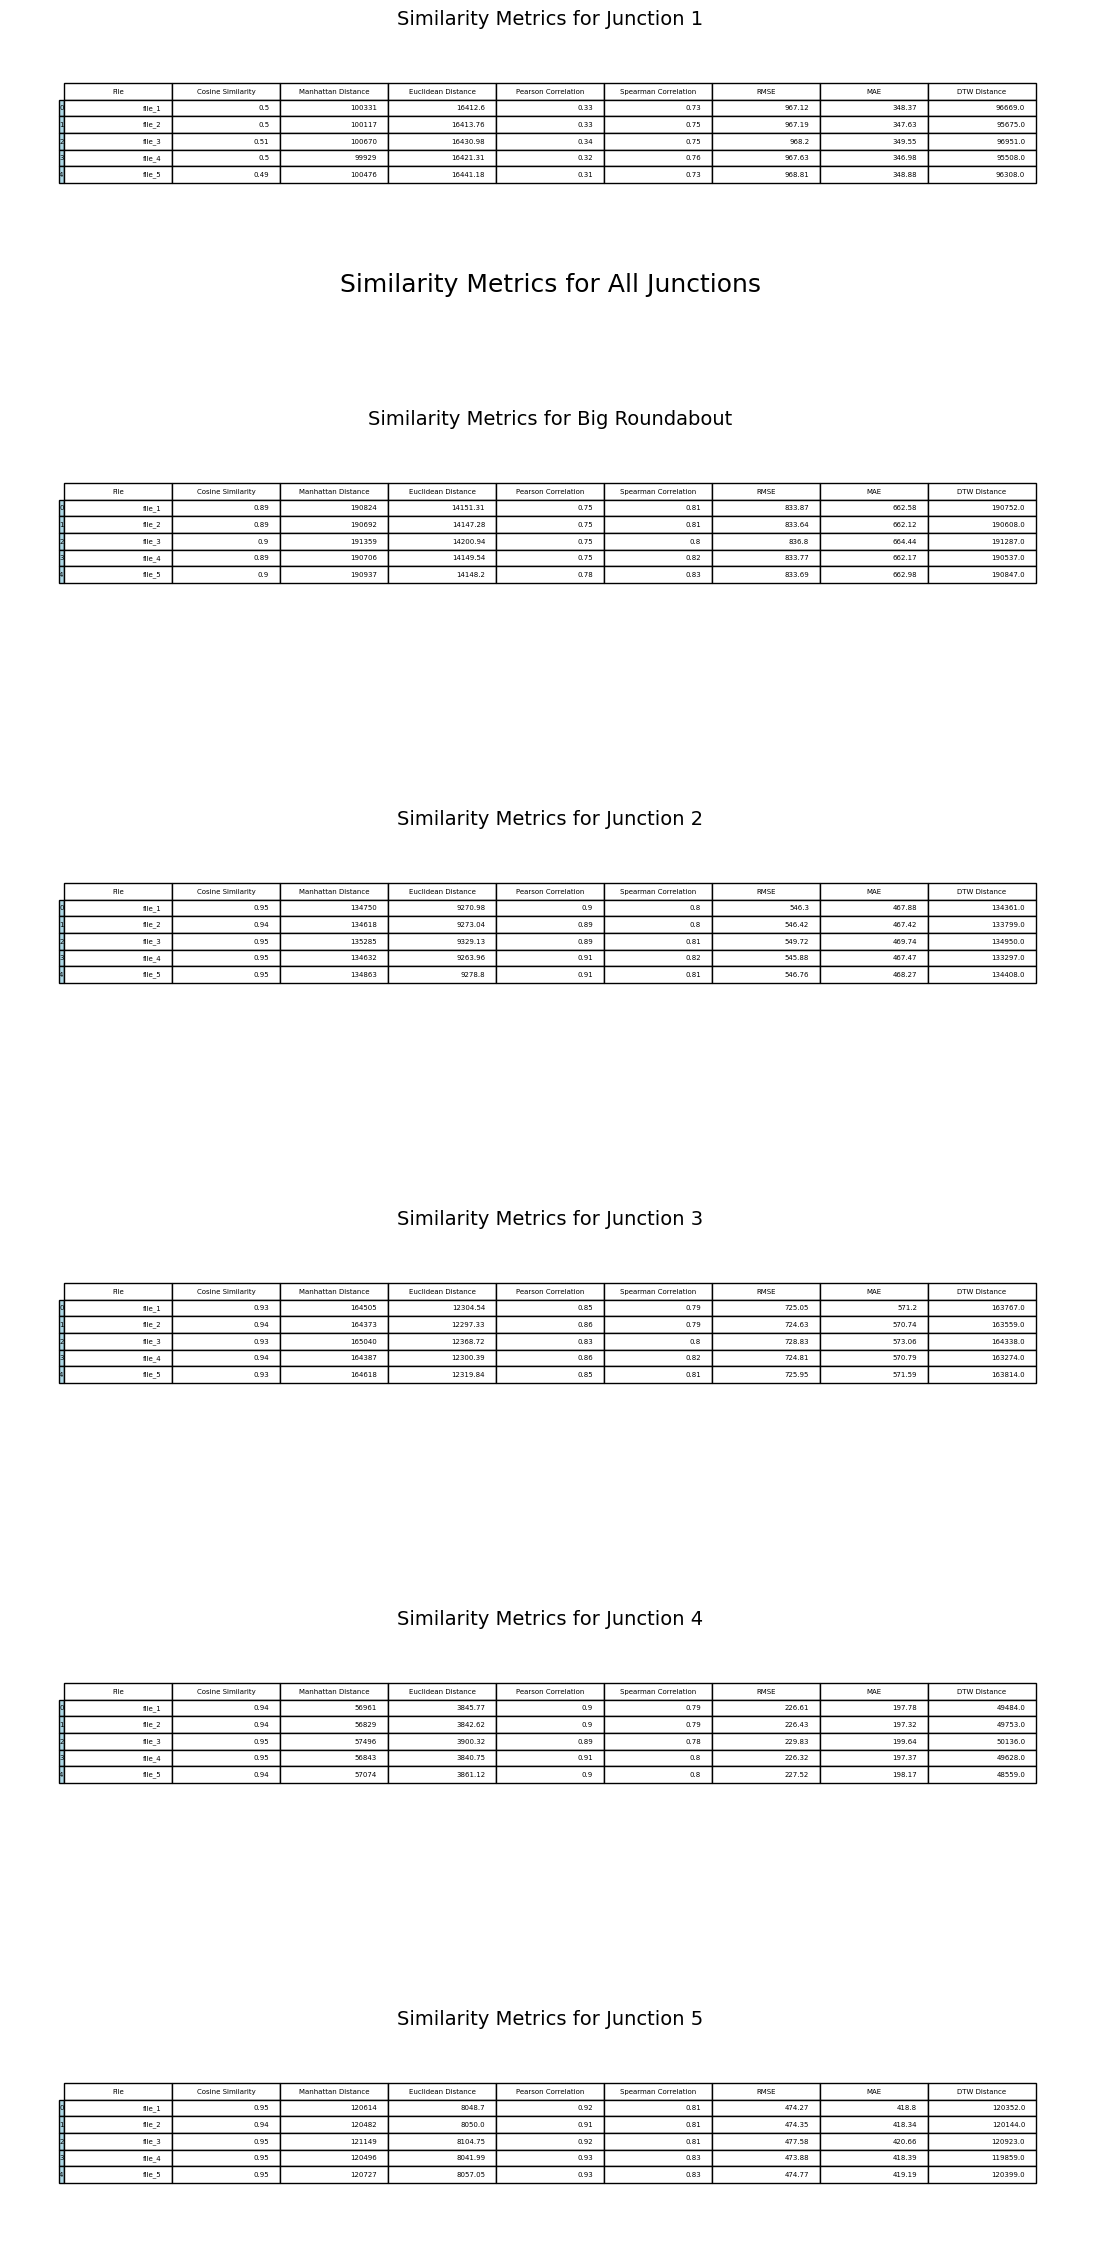

In [127]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean, cityblock
from scipy.stats import pearsonr, spearmanr
from fastdtw import fastdtw
from pandas.plotting import table

# === Read merged (real) data ===
merged_data = pd.read_csv("/content/merged_right_lane_counts.csv")
merged_data = merged_data.dropna(axis=1, how='all')  # drop empty columns

if 'Unnamed: 8' in merged_data.columns:
    merged_data = merged_data.drop(columns=['Unnamed: 8'])

merged_data['Time'] = pd.to_datetime(merged_data['Time'], format='%H:%M:%S', errors='coerce')
merged_data = merged_data.dropna(subset=['Time'])
merged_data.set_index('Time', inplace=True)

# === Read junction (simulated) data ===
junction_data = pd.read_csv("/content/junction_data.csv")
junction_data['Time'] = pd.to_datetime(junction_data['Time'], unit='s')

# === Resample Data ===
# Resample merged data to 5-minute intervals
merged_5min = merged_data.resample('5min').sum()

# Resample junction data to 5-minute intervals
junction_5min = junction_data.resample('5min', on='Time').sum()

# === Similarity Metrics Calculation ===
def compare_time_series(junction_data, merged_data):
    results = {}

    for junction_col in junction_data.columns:  # Loop over each junction's data
        file_comparison = []

        for i in range(1, 6):  # Loop over file_1 to file_5 in merged_data
            file_col = f"file_{i}"

            # Extract values from both time series
            junction_values = junction_data[junction_col].values
            file_values = merged_data[file_col].values

            # Calculate metrics for each file
            comparison_metrics = {
                "File": file_col,
                "Cosine Similarity": round(cosine_similarity([junction_values], [file_values])[0][0], 2),
                "Manhattan Distance": round(cityblock(junction_values, file_values), 2),
                "Euclidean Distance": round(euclidean(junction_values, file_values), 2),
                "Pearson Correlation": round(pearsonr(junction_values, file_values)[0], 2),
                "Spearman Correlation": round(spearmanr(junction_values, file_values)[0], 2),
                "RMSE": round(np.sqrt(np.mean((junction_values - file_values) ** 2)), 2),
                "MAE": round(np.mean(np.abs(junction_values - file_values)), 2),
                "DTW Distance": round(fastdtw(junction_values, file_values)[0], 2)
            }
            file_comparison.append(comparison_metrics)

        # Store the results for the current junction column
        results[junction_col] = pd.DataFrame(file_comparison)

    return results

# Calculate similarity scores for each junction and file pair
similarities = compare_time_series(junction_5min, merged_5min)

# === Plotting ===
# Plot each junction and file pair
merged_cols = [col for col in merged_5min.columns if 'file_' in col]
junction_cols = [col for col in junction_5min.columns if col != 'Time']

# Determine the number of rows needed for plots
num_rows = max(len(merged_cols), len(junction_cols))

fig, axes = plt.subplots(num_rows, 2, figsize=(14, num_rows * 3))
fig.suptitle("KR Circle Merged Data vs Junction Data (per 5 Minutes)", fontsize=16)

# Ensure axes is always 2D
if num_rows == 1:
    axes = [axes]

for i in range(num_rows):
    # Plot merged data (left)
    if i < len(merged_cols):
        axes[i][0].plot(merged_5min[merged_cols[i]], label=merged_cols[i], color="black")
        axes[i][0].set_title(f"KR Circle Merged: {merged_cols[i]}")
    else:
        axes[i][0].axis('off')

    # Plot junction data (right)
    if i < len(junction_cols):
        axes[i][1].plot(junction_5min[junction_cols[i]], label=junction_cols[i], color="blue")
        axes[i][1].set_title(f"Junction: {junction_cols[i]}")
    else:
        axes[i][1].axis('off')

    for j in range(2):
        axes[i][j].set_xlabel("Time")
        axes[i][j].set_ylabel("Vehicle Count")
        axes[i][j].legend()
        axes[i][j].grid(True)
        axes[i][j].set_xticklabels([])  # Remove x-axis tick labels

plt.tight_layout(rect=[0, 0, 1, 0.96])

# === Combining All Similarity Tables into One Image ===
# Create a single figure for all tables
fig_table = plt.figure(figsize=(12, 20))  # Adjust the size to fit all tables
fig_table.suptitle("Similarity Metrics for All Junctions", fontsize=18)

# Start the initial y-position for the first table
y_pos = 1

for junction, df in similarities.items():
    # Create a new subplot for each table
    ax_table = fig_table.add_axes([0.05, y_pos, 0.9, 0.1])  # Adjust the axes position
    ax_table.axis('off')

    # Title for the table
    ax_table.set_title(f"Similarity Metrics for {junction}", fontsize=14)

    # Create a table from the DataFrame and plot it with larger font size for both the values and the header
    table(ax_table, df, loc='center', colWidths=[0.1] * len(df.columns), fontsize=18, rowColours=["lightblue"]*len(df))

    # Update the y-position for the next table
    y_pos -= 0.2  # Adjust spacing between tables (make sure it fits in the image)

# Save the combined table image
table_image_path = "/content/all_similarity_tables.png"
fig_table.savefig(table_image_path, bbox_inches='tight')
print(f"Combined table image saved at {table_image_path}")

# Optionally, save the final graph as an image
fig.savefig("/content/merged_vs_junction_plots.png")
print("Plot saved as 'merged_vs_junction_plots.png'")


In [ ]:
`